<a href="https://colab.research.google.com/github/wavymejti/KursAI1/blob/main/regresja_logistyczna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

● Wygenerować cztery różne zestawy danych treningowych (czas, wynik
= zdane/niezdane).

● Dla każdego zestawu wytrenować model regresji logistycznej.

● Narysować 4 osobne wykresy – na każdym punkty treningowe i
dopasowana krzywa.

● Na końcu narysować 5. wykres, który pokazuje wszystkie cztery
krzywe razem, aby porównać, jak wyglądają różne modele.

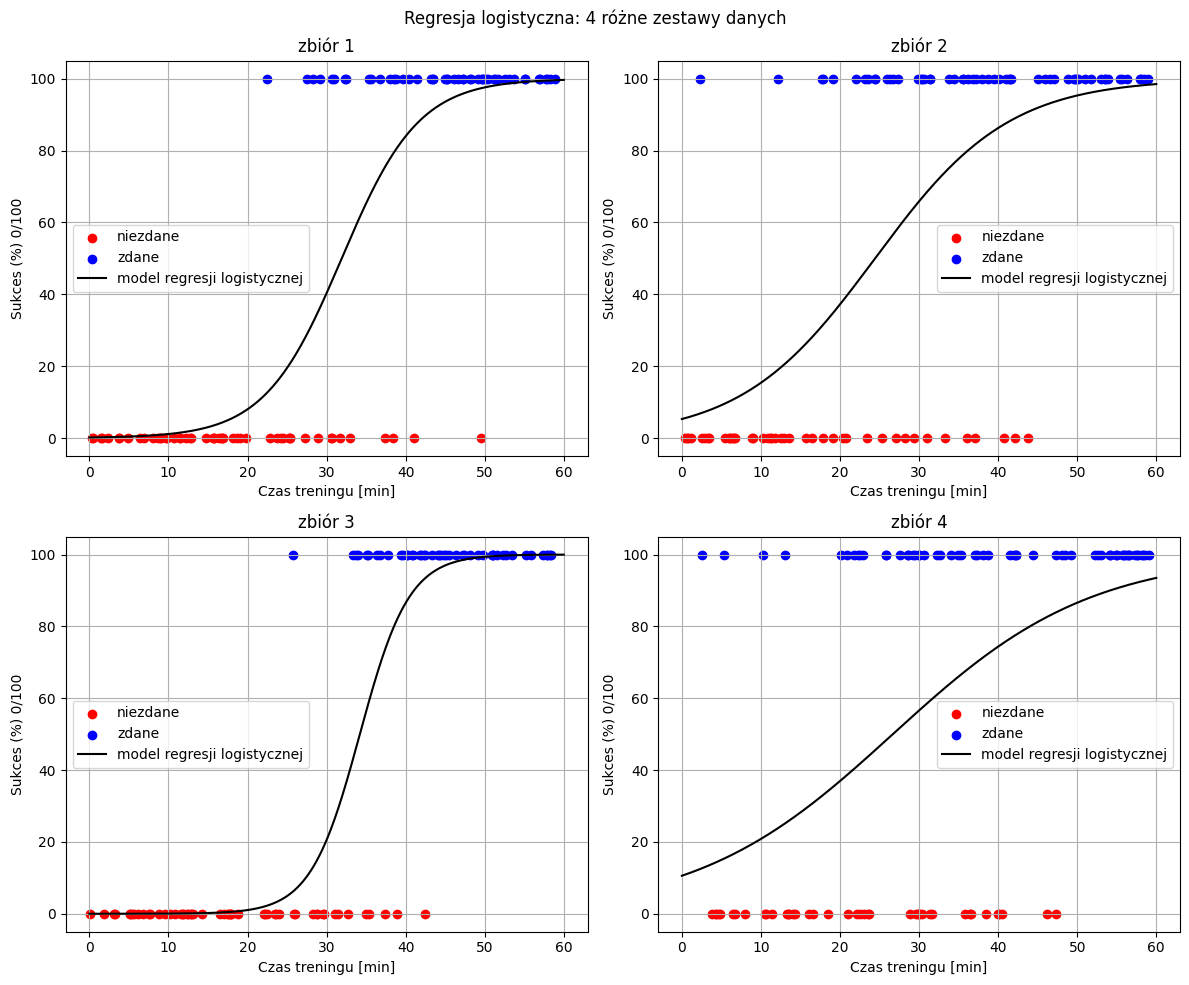

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

#funkcja ktora generuje zbiory danych
def generuj_zbior(n, seed, k_true, x0_true):
  rng = np.random.default_rng(seed)
  czas = rng.uniform(0, 60, n)
  prawd = 1/(1 + np.exp(-k_true * (czas - x0_true)))
  wynik = rng.binomial(1, prawd)
  return czas, wynik

#definiowanie 4 zestawow
zbiory = [
    {"n" : 100, "seed" : 1,  "k_true" : 0.2, "x0_true" : 30, "etykieta" : "zbiór 1"},
    {"n" : 100, "seed" : 2,  "k_true" : 0.15, "x0_true" : 25, "etykieta" : "zbiór 2"},
    {"n" : 100, "seed" : 3,  "k_true" : 0.25, "x0_true" : 35, "etykieta" : "zbiór 3"},
    {"n" : 100, "seed" : 4,  "k_true" : 0.1, "x0_true" : 28, "etykieta" : "zbiór 4"}
]

# siatka do rysowania krzywej
siatka = np.linspace(0, 60, 500).reshape(-1, 1)

# 4 oddzielne wykresy
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

krzywe = []
for i, zbior in enumerate(zbiory):
  czas, wynik = generuj_zbior(zbior["n"], zbior["seed"], zbior["k_true"], zbior["x0_true"])
  X = czas.reshape(-1, 1)
  model = LogisticRegression()
  model.fit(X, wynik)
  przewidziane = model.predict_proba(siatka)[:, 1]
  krzywe.append((przewidziane, zbior['etykieta']))
  # punkty uczace
  axs[i].scatter(czas[wynik == 0], wynik[wynik == 0] * 100, color='red', label='niezdane')
  axs[i].scatter(czas[wynik == 1], wynik[wynik == 1] * 100, color='blue', label='zdane')
  # krzywa
  axs[i].plot(siatka, przewidziane * 100, color='black', label='model regresji logistycznej')
  #opisy
  axs[i].set_xlabel('Czas treningu [min]')
  axs[i].set_ylabel('Sukces (%) 0/100')
  axs[i].set_title(zbior['etykieta'])
  axs[i].grid()
  axs[i].legend()

plt.suptitle("Regresja logistyczna: 4 różne zestawy danych")
plt.tight_layout()
plt.show()

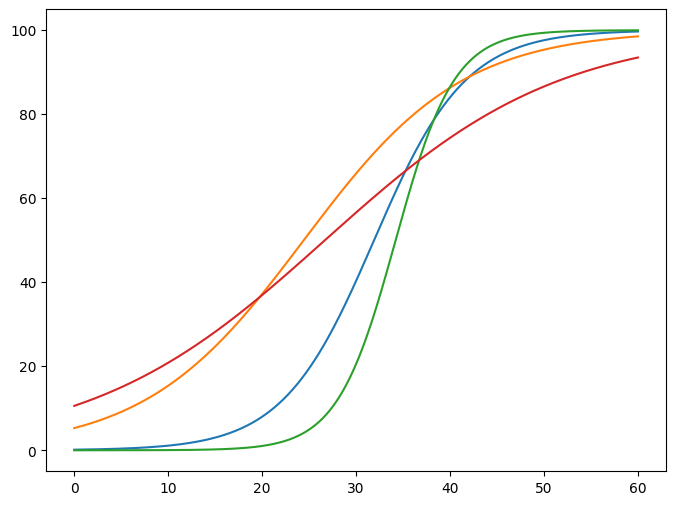

In [4]:
# WSZYSTKIE KRZYWE RAZEM
plt.figure(figsize=(8, 6))
for krzywa in krzywe:
  plt.plot(siatka, krzywa[0] * 100, label=krzywa[1])

In [8]:
#uczenie modelu
modele = []
for zbior in zbiory:
  czas, y = generuj_zbior(zbior["n"], zbior["seed"], zbior["k_true"], zbior["x0_true"])
  X = czas.reshape(-1, 1)
  clf = LogisticRegression()
  clf.fit(X, y)
  modele.append((zbior['etykieta'],clf))

# podaj swoje 10 czasow
czas_testowy = np.array([20, 25, 30, 35, 40, 45, 50, 55])
X_test = np.array(czas_testowy, dtype='float').reshape(-1, 1)

#tabela wynikow
kolumny = ['czas[min]']
wiersze = [[t] for t in czas_testowy]

for etykieta, clf in modele:
  proba = clf.predict_proba(X_test)[:, 1]
  proba_proc = [round(p * 100) for p in proba]
  kolumny += [etykieta]
  for i in range(len(wiersze)):
    wiersze[i] += [proba_proc[i]]
import pandas as pd
df = pd.DataFrame(wiersze, columns=kolumny)
df

,czas[min],zbiór 1,zbiór 2,zbiór 3,zbiór 4
0,20,8,37,1,37
1,25,19,52,5,47
2,30,40,66,21,57
3,35,65,78,56,66
4,40,84,86,87,74
5,45,94,92,97,81
6,50,98,95,99,87
7,55,99,97,100,91
